<a href="https://colab.research.google.com/github/EkaterinaLavlinskaya/ai-career-log/blob/main/ai_career_logger.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install PyGithub

In [ ]:



# Подключаем нужные инструменты
from github import Github
import pandas as pd
from datetime import datetime
import json
from google.colab import userdata


# Название репозитория
REPO_NAME = "EkaterinaLavlinskaya/ai-career-log"

FILE_PATH = "data/interactions.jsonl"


# Берём токен
try:
    GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
    print("✅ Токен загружен из секретов Colab.")
except Exception as e:
    print("❌ Не удалось загрузить токен.")

    raise

# Подключаемся к GitHub
g = Github(GITHUB_TOKEN)

# Проверяем, достучались ли до репозитория
try:
    repo = g.get_repo(REPO_NAME)
    print(f"✅ Подключились к репозиторию: {REPO_NAME}")
except Exception as e:
    print(f"❌ Ошибка: не могу найти репозиторий {REPO_NAME}. Проверь название.")
    raise



# Функция для чтения текущих данных из файла
def get_current_data(g):
    repo = g.get_repo(REPO_NAME)
    contents = repo.get_contents(FILE_PATH)
    content = contents.decoded_content.decode('utf-8')
    # Хитрость, чтобы загрузить JSONL в pandas
    import io
    df = pd.read_json(io.StringIO(content), lines=True)
    return df, contents.sha

# Функция для добавления новой записи
def add_record(g, new_data):
    repo = g.get_repo(REPO_NAME)
    contents = repo.get_contents(FILE_PATH)
    current_content = contents.decoded_content.decode('utf-8')
    current_sha = contents.sha

    # Берём последнюю запись, чтобы узнать текущие счётчики (проекты, отклики и т.д.)
    import io
    df = pd.read_json(io.StringIO(current_content), lines=True)
    last = df.iloc[-1].to_dict()

    # Собираем новую запись
    record = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "session_id": last.get("session_id", "001"),
        "topic": new_data.get("topic", "update"),
        "projects": new_data.get("projects", last["projects"]),
        "certificates": new_data.get("certificates", last["certificates"]),
        "days_continuous": new_data.get("days_continuous", last["days_continuous"]),
        "applications": new_data.get("applications", last["applications"]),
        "positive_responses": new_data.get("positive_responses", last["positive_responses"]),
        "tests": new_data.get("tests", last["tests"]),
        "note": new_data.get("note", "")
    }

    # Добавляем новую строку к текущему содержимому
    new_line = json.dumps(record, ensure_ascii=False)
    updated_content = current_content + "\n" + new_line

    # Отправляем обновлённый файл обратно на GitHub
    repo.update_file(
        path=FILE_PATH,
        message=f"Добавлена запись: {record['topic']}",
        content=updated_content.encode('utf-8'),
        sha=current_sha
    )
    print(f"✅ Запись добавлена!")
    print(f"   Тема: {record['topic']}")
    print(f"   Примечание: {record['note']}")
    return record

# --- ТЕСТ: добавляем первую запись ---
print("\n" + "="*50)
print("Пробуем добавить тестовую запись...")

test_record = add_record(g, {
    "topic": "проверка_скрипта",
    "note": "Проверяем, как работает автоматическое добавление записей"
})

# --- ПРОВЕРКА: читаем обновлённые данные ---
print("\n" + "="*50)
print("Последние 2 записи в файле:")
df_updated, _ = get_current_data(g)
print(df_updated.tail(2))

✅ Токен загружен из секретов Colab.


/tmp/ipykernel_1539/2671421954.py:25: DeprecationWarning: Argument login_or_token is deprecated, please use auth=github.Auth.Token(...) instead
  g = Github(GITHUB_TOKEN)


✅ Подключились к репозиторию: EkaterinaLavlinskaya/ai-career-log

Пробуем добавить тестовую запись...
✅ Запись добавлена!
   Тема: проверка_скрипта
   Примечание: Проверяем, как работает автоматическое добавление записей

Последние 2 записи в файле:
            timestamp  session_id             topic  projects  certificates  \
1 2026-03-20 06:36:00           1  проверка_скрипта         9            10   
2 2026-03-20 06:40:00           1  проверка_скрипта         9            10   

   days_continuous  applications  positive_responses  tests  \
1               42             7                   3      1   
2               42             7                   3      1   

                                                note  
1  Проверяем, как работает автоматическое добавле...  
2  Проверяем, как работает автоматическое добавле...  


In [ ]:
import pandas as pd


url = "https://raw.githubusercontent.com/EkaterinaLavlinskaya/ai-career-log/main/data/interactions.jsonl"

logs = pd.read_json(url, lines=True)

print("Первые записи:")
print(logs.head())


Первые записи:
            timestamp  session_id             topic  projects  certificates  \
0 2026-03-20 00:00:00           1     initial_state         9            10   
1 2026-03-20 06:36:00           1  проверка_скрипта         9            10   
2 2026-03-20 06:40:00           1  проверка_скрипта         9            10   

   days_continuous  applications  positive_responses  tests  \
0               42             7                   3      1   
1               42             7                   3      1   
2               42             7                   3      1   

                                                note  
0                                     старт датасета  
1  Проверяем, как работает автоматическое добавле...  
2  Проверяем, как работает автоматическое добавле...  


In [ ]:
print("\n📊 Статистика:")
print(f"Всего записей: {len(logs)}")
print(f"Последняя запись: {logs.iloc[-1]['timestamp']}")
print(f"Всего проектов сейчас: {logs.iloc[-1]['projects']}")
print(f"Всего откликов: {logs.iloc[-1]['applications']}")


📊 Статистика:
Всего записей: 1
Последняя запись: 2026-03-20 00:00:00
Всего проектов сейчас: 9
Всего откликов: 7


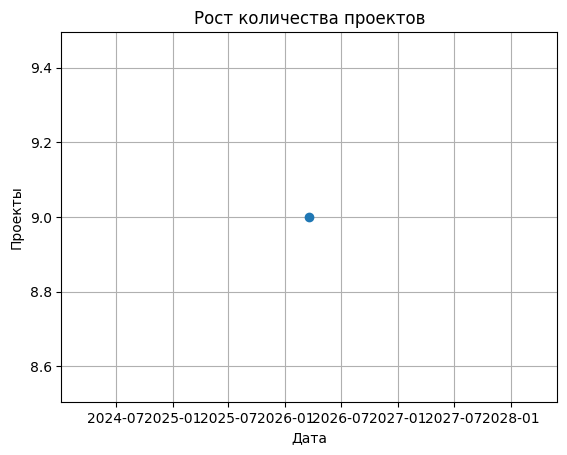

In [ ]:
import matplotlib.pyplot as plt

logs['timestamp'] = pd.to_datetime(logs['timestamp'])
plt.plot(logs['timestamp'], logs['projects'], marker='o')
plt.title('Рост количества проектов')
plt.xlabel('Дата')
plt.ylabel('Проекты')
plt.grid(True)
plt.show()

In [38]:
# ========== КНОПКИ ДЛЯ БЫСТРОГО ЛОГИРОВАНИЯ ==========
# Запусти эту ячейку — появятся кнопки для каждого события

import ipywidgets as widgets
from IPython.display import display, clear_output
import json
from datetime import datetime
import pandas as pd
import io

# Функция для логирования с кнопки
def log_from_button(topic, note=""):
    try:
        new_record = add_record(g, {
            "topic": topic,
            "note": note
        })
        print(f"✅ {topic}: {note}")
        print(f"   timestamp: {new_record['timestamp']}")
    except Exception as e:
        print(f"❌ Ошибка: {e}")

# Создаём кнопки
button_project = widgets.Button(
    description='📁 Новый проект',
    button_style='success',
    tooltip='Добавить запись о новом проекте'
)

button_apply = widgets.Button(
    description='📬 Новый отклик',
    button_style='info',
    tooltip='Добавить отклик на вакансию'
)

button_test = widgets.Button(
    description='🧪 Новый тест',
    button_style='warning',
    tooltip='Добавить пройденный тест'
)

button_cert = widgets.Button(
    description='🎓 Новый сертификат',
    button_style='primary',
    tooltip='Добавить полученный сертификат'
)

button_day = widgets.Button(
    description='✅ Очередной день',
    button_style='',
    tooltip='Отметить прожитый день'
)

button_interview = widgets.Button(
    description='🤝 Собеседование',
    button_style='danger',
    tooltip='Добавить собеседование'
)

button_offer = widgets.Button(
    description='🎉 Оффер!',
    button_style='success',
    tooltip='Добавить полученный оффер'
)

# Поле для ввода заметки
note_input = widgets.Text(
    value='',
    placeholder='короткое описание события',
    description='Заметка:',
    layout=widgets.Layout(width='100%')
)

# Кнопка для произвольного события
custom_topic = widgets.Text(
    value='',
    placeholder='например: rejection',
    description='Тема:',
    layout=widgets.Layout(width='40%')
)

custom_note = widgets.Text(
    value='',
    placeholder='описание',
    description='Заметка:',
    layout=widgets.Layout(width='60%')
)

button_custom = widgets.Button(
    description='➕ Своё событие',
    button_style='',
    tooltip='Добавить произвольное событие'
)

# Обработчики нажатий
def on_project_click(b):
    log_from_button("project", note_input.value)
    note_input.value = ''  # очищаем поле

def on_apply_click(b):
    log_from_button("application", note_input.value)
    note_input.value = ''

def on_test_click(b):
    log_from_button("test", note_input.value)
    note_input.value = ''

def on_cert_click(b):
    log_from_button("certificate", note_input.value)
    note_input.value = ''

def on_day_click(b):
    log_from_button("daily", "очередной день")
    # поле не очищаем — оно для заметок, а тут заметка стандартная

def on_interview_click(b):
    log_from_button("interview", note_input.value)
    note_input.value = ''

def on_offer_click(b):
    log_from_button("offer", note_input.value)
    note_input.value = ''

def on_custom_click(b):
    if custom_topic.value:
        log_from_button(custom_topic.value, custom_note.value)
        custom_topic.value = ''
        custom_note.value = ''
    else:
        print("❌ Укажи тему события")

# Привязываем обработчики
button_project.on_click(on_project_click)
button_apply.on_click(on_apply_click)
button_test.on_click(on_test_click)
button_cert.on_click(on_cert_click)
button_day.on_click(on_day_click)
button_interview.on_click(on_interview_click)
button_offer.on_click(on_offer_click)
button_custom.on_click(on_custom_click)

# Размещаем всё на экране
print("📋 Нажми кнопку, чтобы добавить запись (заметка необязательна)")
display(note_input)

print("\n🔹 ОСНОВНЫЕ СОБЫТИЯ:")
display(widgets.HBox([button_project, button_apply, button_test, button_cert]))

print("\n🔹 КАРЬЕРНЫЕ СОБЫТИЯ:")
display(widgets.HBox([button_interview, button_offer, button_day]))

print("\n🔹 ПРОИЗВОЛЬНОЕ СОБЫТИЕ:")
display(widgets.HBox([custom_topic, custom_note, button_custom]))

print("\n💡 Совет: после добавления записи запусти дашборд, чтобы увидеть обновления")

📋 Нажми кнопку, чтобы добавить запись (заметка необязательна)


Text(value='', description='Заметка:', layout=Layout(width='100%'), placeholder='короткое описание события')


🔹 ОСНОВНЫЕ СОБЫТИЯ:



🔹 КАРЬЕРНЫЕ СОБЫТИЯ:



🔹 ПРОИЗВОЛЬНОЕ СОБЫТИЕ:



💡 Совет: после добавления записи запусти дашборд, чтобы увидеть обновления
